In [6]:
import pandas as pd
import numpy as np

In [7]:
# Load dataset
df = pd.read_csv("/content/hospital_readmissions_30k.csv")

print(df.shape)
df.head()

(30000, 12)


,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64


In [9]:
# Remove patient ID
df = df.drop("patient_id", axis=1)

# Separate features and target
X = df.drop("readmitted_30_days", axis=1)
y = df["readmitted_30_days"]

# Encode only the feature columns
X = pd.get_dummies(X, drop_first=True, dtype=int)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(24000, 1591)
(6000, 1591)


In [11]:
from sklearn.linear_model import LogisticRegression

logmodel = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000
)

logmodel.fit(X_train, y_train)

print(logmodel.coef_)
print(logmodel.intercept_)

[[-8.97980760e-05  2.37238601e-04 -8.61576262e-03 ...  1.67257695e-01
   6.27239932e-01  7.20395150e-01]]
[-2.24518978]


In [12]:
predictions = logmodel.predict(X_test)
print(predictions)

['No' 'No' 'No' ... 'No' 'No' 'No']


In [13]:
# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))




Confusion Matrix:
[[5264    1]
 [ 735    0]]


In [14]:
print("Accuracy:")
print(accuracy_score(y_test, predictions))

Accuracy:
0.8773333333333333


In [15]:
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

          No       0.88      1.00      0.93      5265
         Yes       0.00      0.00      0.00       735

    accuracy                           0.88      6000
   macro avg       0.44      0.50      0.47      6000
weighted avg       0.77      0.88      0.82      6000



In [16]:
probabilities = logmodel.predict_proba(X_test)[:, 1]
print(probabilities[:10])
print("ROC-AUC Score:")
print(roc_auc_score(y_test, probabilities))

[0.20625309 0.1604034  0.06642762 0.15201905 0.22038861 0.09535613
 0.13720704 0.30440791 0.19509856 0.07277804]
ROC-AUC Score:
0.5396060494473193


In [17]:
# False Negatives vs False Positives
cm = confusion_matrix(y_test, predictions)

print("False Positives (wrongly flagged as risky):", cm[0, 1])
print("False Negatives (missed readmissions)     :", cm[1, 0])

False Positives (wrongly flagged as risky): 1
False Negatives (missed readmissions)     : 735


In [23]:
import matplotlib.pyplot as plt

In [24]:
probabilities = logmodel.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probabilities, pos_label="Yes")

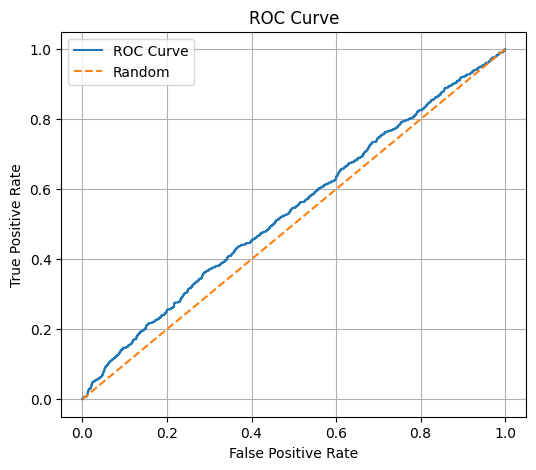

In [26]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, probabilities, pos_label="Yes")

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], "--", label="Random")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()